In [2]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
import matplotlib.pyplot as plt
import sympy
import random
from ase.io import read

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [3]:
from sympy import symbols, simplify, sin, expand
import sympy as sp
import pymc as pm
import arviz as az

In [4]:
atoms_train = read("/home/paolo/Na_dataset/train_Na_new.xyz", index=":")
atoms_test = read("/home/paolo/Na_dataset/test_Na_new.xyz", index=":")

In [5]:
data_train = pd.concat(
    [pd.DataFrame([a.info for a in atoms_train]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_train]})],
    axis=1
)
data_test = pd.concat(
    [pd.DataFrame([a.info for a in atoms_test]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_test]})],
    axis=1
)

In [5]:
data_train

,Ea,B,N,O,F,Na,Al,Si,P,S,...,face-area-max,face-area-avg,face-area-min,face-area-count,pockets-per-ion,pockets-per-volume,paths-per-ion,paths-per-volume,poly_dist_avg_fixed,cub_root_V
0,0.365113,0.000000,0.0,0.631387,0.000000,0.127737,0.000000,0.000000,0.171533,0.000000,...,10.973040,2.521378,2.554994e-06,24.784055,5.371429,0.046887,45.342857,0.395793,0.385197,25.218719
1,0.425024,0.000000,0.0,0.467925,0.000000,0.184906,0.000000,0.000000,0.135849,0.000000,...,11.777366,2.837638,8.278834e-07,29.008265,1.173469,0.011507,5.484694,0.053782,0.375974,27.138803
2,0.274638,0.113043,0.0,0.000000,0.000000,0.208696,0.108696,0.000000,0.000000,0.304348,...,15.033404,3.383426,2.368494e-11,39.474009,2.583333,0.021100,14.566667,0.118978,0.080752,30.858072
3,0.324737,0.000000,0.0,0.000000,0.000000,0.101124,0.000000,0.243446,0.033708,0.621723,...,12.877547,3.444336,5.345359e-06,40.587672,8.425926,0.032273,51.564815,0.197504,0.116010,30.436900
4,0.345059,0.000000,0.0,0.407692,0.000000,0.219231,0.000000,0.000000,0.161538,0.000000,...,15.090982,3.165906,4.092372e-09,35.067899,2.105263,0.021466,13.359649,0.136222,0.363843,28.172671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,0.321759,0.000000,0.0,0.000000,0.000000,0.241935,0.000000,0.000000,0.161290,0.451613,...,12.864103,3.268545,4.741584e-07,37.803003,1.360784,0.012972,5.980392,0.057011,0.091131,29.906856
1037,0.389788,0.000000,0.0,0.380711,0.106599,0.335025,0.177665,0.000000,0.000000,0.000000,...,8.761876,1.934795,1.569696e-06,12.466122,0.335859,0.008334,2.255051,0.055958,0.317510,25.176614
1038,0.393305,0.250000,0.0,0.500000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,...,8.829005,1.864119,7.645468e-07,13.897762,0.412000,0.008600,1.924000,0.040160,0.368284,22.879676
1039,0.335168,0.000000,0.0,0.417969,0.000000,0.187500,0.000000,0.000000,0.027344,0.000000,...,13.544451,2.987695,7.102955e-06,32.194261,3.026042,0.029022,16.453125,0.157799,0.301010,27.152839


In [6]:
def initialize_units(df_iniz, med_flag = False):
    '''
    Zeta standardization of the dimensionful features
    '''
    df = (df_iniz - df_iniz.mean()) / df_iniz.std()
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    return {
        "E" : np.array(df['Ea'], dtype = 'float'),
        "cub_root_V" : np.array(df['cub_root_V'], dtype = 'float'),
        
        # Density in g/cm^3
        "density": np.array(df['density'], dtype='float'),
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float'),
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float'),
        # -Na-Na (are just the Na-Na distances)
        "Na-Na": np.array(df['Na-Na'], dtype='float'),
        "Na-Na-max": np.array(df['Na-Na-max'], dtype='float'),
        "Na-Na-avg": np.array(df['Na-Na-avg'], dtype='float'),
        # -bottleneck (free distance available for a Na⁺ ion to pass through the narrowest part of a diffusion pathway formed by surrounding framework atoms (typically O²⁻, S²⁻, or halides))
        "bottleneck_min": np.array(df['bottleneck_min'], dtype='float'),
        "bottleneck_avg": np.array(df['bottleneck_avg'], dtype='float'),
        # -face-area   (area of the shared face between two neighboring Voronoi polyhedra corresponding to adjacent Na sites it represents the cross-sectional area available for Na⁺ migration between those sites)
        "face-area-max": np.array(df['face-area-max'], dtype='float'),
        "face-area-avg": np.array(df['face-area-avg'], dtype='float'),
        "face-area-min": np.array(df['face-area-min'], dtype='float'),
        # -pockets  (free-volume region in the crystal structure where a Na⁺ ion can reside with relatively low energy, typically corresponding to a stable or metastable Na site)
        "pockets-per-volume": np.array(df['pockets-per-volume'], dtype='float'),
        # -paths  (connected sequence of pockets linked by Voronoi faces and constrained by bottlenecks, forming a continuous route that allows Na⁺ ions to move through the crystal lattice)
        "paths-per-volume": np.array(df['paths-per-volume'], dtype='float')
    }

## SISSO initialization

In [11]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "E_T": data_train['Ea']/(kb*T),
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "ln_D": data_train['logD']
})    

In [8]:
n_feat = 40
lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/final/Na_lndiff{n_feat}_temp300_unitless3.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/final/Na_lndiff{n_feat}_temp300_unitless3.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [10]:
# Try the fit with the exact functional form
rung = 2
desc_dim = 1
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/final/lndiff{n_feat}_{rung}_{desc_dim}_unitless.json", "w"), indent=4)

## Extract the Forumlas

In [12]:
def extract_rung2(ms = 10, rung=2, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=1 and Rung=2'''
    dd = 1
    formulas = []
    a0_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/final/models_lndiff{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            c0_i = parts[4].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, c0_list)

In [13]:
raw_formulas, a0_list, c0_list = extract_rung2()

In [14]:
raw_formulas

['c0 + a0 * ((O * WE) - (face-area-avg - E_T))',
 'c0 + a0 * ((O + E_T) - (face-area-avg - O))',
 'c0 + a0 * ((O / NBI) - (face-area-avg - E_T))',
 'c0 + a0 * ((Al + E_T) - (face-area-avg - O))',
 'c0 + a0 * ((O + E_T) - (face-area-avg - SBI))',
 'c0 + a0 * ((S - E_T) + (face-area-avg - O))',
 'c0 + a0 * ((O / PF) - (face-area-avg - E_T))',
 'c0 + a0 * ((O + E_T) - (face-area-avg - poly_dist_avg_fixed))',
 'c0 + a0 * (exp(O) - (face-area-avg - E_T))',
 'c0 + a0 * ((face-area-avg - E_T) - (poly_dist_avg + O))']

In [15]:
def sanitize(expr):
    '''
    Fix Descriptor names
    '''
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [16]:
formulas = [sanitize(f) for f in raw_formulas]
formulas

['c0 + a0 * ((O * WE) - (face_area_avg - E_T))',
 'c0 + a0 * ((O + E_T) - (face_area_avg - O))',
 'c0 + a0 * ((O / NBI) - (face_area_avg - E_T))',
 'c0 + a0 * ((Al + E_T) - (face_area_avg - O))',
 'c0 + a0 * ((O + E_T) - (face_area_avg - SBI))',
 'c0 + a0 * ((S - E_T) + (face_area_avg - O))',
 'c0 + a0 * ((O / PF) - (face_area_avg - E_T))',
 'c0 + a0 * ((O + E_T) - (face_area_avg - poly_dist_avg_fixed))',
 'c0 + a0 * (exp(O) - (face_area_avg - E_T))',
 'c0 + a0 * ((face_area_avg - E_T) - (poly_dist_avg + O))']

In [17]:
a0 = np.array(a0_list, dtype=float)
c0 = np.array(c0_list, dtype=float)

In [18]:
# Coefficients are separated from function blocks to be later added as distributions
a0_sym, c0_sym = sp.symbols('a0 c0')
symbols = sp.symbols(
    '''
    E_T B N O F Na Al Si P S Cl Ge Br I
    density AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym))
    ]
    pruned.append(row)

pruned

[[E_T + O*WE - face_area_avg],
 [E_T + 2*O - face_area_avg],
 [E_T - face_area_avg + O/NBI],
 [Al + E_T + O - face_area_avg],
 [E_T + O + SBI - face_area_avg],
 [-E_T - O + S + face_area_avg],
 [E_T + O/PF - face_area_avg],
 [E_T + O - face_area_avg + poly_dist_avg_fixed],
 [E_T - face_area_avg + exp(O)],
 [-E_T - O + face_area_avg - poly_dist_avg]]

In [19]:
vars_ = [
    locals_dict[k] for k in [
        "E_T", 'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'density', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [20]:
data = initialize_units(data_train)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X = np.array([
    phi(
        data_train['Ea']/(kb*T),
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [21]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X_test = np.array([
    phi(
        data_test['Ea']/(kb*T),
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [17]:
# 10 formulas with 3 subformulas each for each of the 1041 entries of the dataset
X.shape, X_test.shape

((10, 1, 1041), (10, 1, 261))

In [18]:
X

array([[[ 16.52576299,  17.76310627,   9.75812089, ...,  18.21686694,
          13.88579597,  19.51699089]],

       [[ 16.01698961,  17.45854921,   9.75812089, ...,  17.98561694,
          13.6223777 ,  19.41838636]],

       [[ 15.71298118,  17.24317285,   9.75812089, ...,  17.79594667,
          13.43818596,  19.22635372]],

       ...,

       [[ 15.77079985,  17.36659855,   9.8388726 , ...,  17.8539011 ,
          13.50541906,  19.36933005]],

       [[ 16.63443226,  18.11937704,  10.75812089, ...,  18.63433821,
          14.30531341,  20.11445279]],

       [[-15.77079985, -17.36659855,  -9.83550794, ..., -17.8539011 ,
         -13.48817369, -19.36323767]]], shape=(10, 1, 1041))

In [23]:
np.max(c0), np.max(a0)

(np.float64(-10.36105414798417), np.float64(0.6820410163641848))

In [21]:
traces1 = []
ppcs = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors weakly informative
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data_train['logD'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        traces1.append(trace)
        ppcs.append(ppc)

        idata = trace.posterior
        az.to_netcdf(idata, f"trace_model_{i}.nc")
        az.to_netcdf(ppc, f"pp_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [23]:
c0[0], a0[0]

(np.float64(-11.39387625825993), np.float64(-0.6562881103083252))

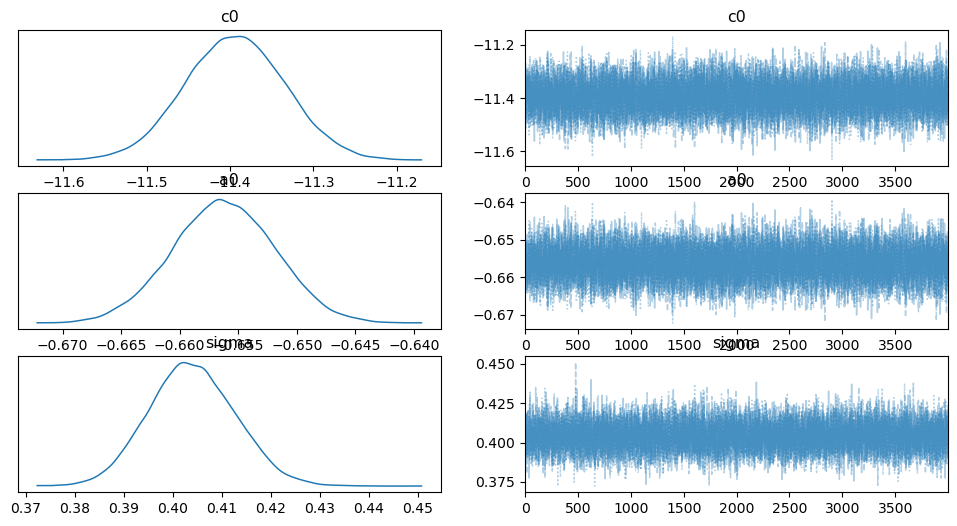

In [24]:
az.plot_trace(traces1[0], combined=True);

In [25]:
# log marginal likelihood for model 0: 6 chains and 11 draws per chain
traces1[1].sample_stats["log_marginal_likelihood"].values 

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-580.4973204974815)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-580.5518632737871)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-580.4924804934913)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-580.3981323164861)]], dtype=object)

In [26]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces1[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-551.13636112 -551.04678135 -550.94569136 -551.06468609]
[-580.4973205  -580.55186327 -580.49248049 -580.39813232]
[-600.38716081 -600.52302812 -600.39761165 -600.24341252]
[-609.39557803 -609.86066963 -609.88976114 -609.69434188]
[-613.6913945  -614.09395934 -613.90022559 -613.91944627]
[-615.61306372 -615.62985157 -615.40625869 -615.665418  ]
[-618.36715591 -618.72627554 -618.59509581 -618.81874051]
[-627.52519761 -627.62878518 -627.69729351 -627.68056297]
[-627.96940056 -628.04864127 -628.12404889 -628.02021056]
[-628.17564018 -627.74762703 -628.39576604 -628.08978189]


In [27]:
log_marginal_likelihoods

[np.float64(-551.0483799824602),
 np.float64(-580.4849491453115),
 np.float64(-600.3878032748903),
 np.float64(-609.7100876684935),
 np.float64(-613.9012564235637),
 np.float64(-615.5786479948706),
 np.float64(-618.6268169427923),
 np.float64(-627.6329598165839),
 np.float64(-628.0405753202563),
 np.float64(-628.1022037863258)]

In [28]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml 

(np.float64(-551.0483799824602), np.int64(0))

In [29]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(1.6438434155325233e-13),
 np.float64(3.733883158692747e-22),
 np.float64(3.338443671620903e-26),
 np.float64(5.0505955282962225e-28),
 np.float64(9.437580878228612e-29),
 np.float64(4.477728244304834e-30),
 np.float64(5.492114453199139e-34),
 np.float64(3.6535446159097547e-34),
 np.float64(3.435180109526688e-34)]

In [30]:
np.argsort(ml_diff)

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

## Tempering

In [20]:
beta = np.array([1/8, 1/4, 1/2])
beta

array([0.125, 0.25 , 0.5  ])

In [21]:
traces_temp = []
models_stored = 10
for i in range(models_stored):
    traces_i = []
    for j in beta:
        with pm.Model() as model:
            # Select the i-th column
            f = X[i, :, :]
            f_test = X_test[i, :, :]
    
            # Priors weakly informative
            c0_coeff = pm.Normal("c0", mu=c0[i], sigma=5)
            a0_coeff = pm.Normal("a0", mu=a0[i], sigma=5)
            sigma = pm.HalfNormal("sigma", sigma=2)
    
            # Linear parametrization
            mu = c0_coeff + a0_coeff * f[0, :]
    
    
            # Standard log-likelihood
            dist = pm.Normal.dist(mu=mu, sigma=sigma)
            logp = pm.logp(dist, data_train['logD'])

            # Tempered likelihood --> log (y| theta) = sum_n log(y_n|theta)
            pm.Potential("tempered_likelihood", j * logp.sum())
    
            # Sample from posterior
            # Sequential montecarlo
            trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)
            #trace = pm.sample()
            traces_i.append(trace)
    traces_temp.append(traces_i)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

In [22]:
traces_temp[0][0].sample_stats["log_marginal_likelihood"].values

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-81.15032011419406)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-81.09069342575411)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-81.11911558642115)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        np.float64(-81.16765098655668)]], dtype=object)

In [23]:
marginal_likelihoods_temp = []
log_marginal_likelihoods_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        log_ml_raw = traces_temp[i][j].sample_stats["log_marginal_likelihood"].values
    
        # Flatten possible nested lists and cast to floats
        flattened = []
        for row in log_ml_raw.ravel():
            # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
            if isinstance(row, (list, tuple, np.ndarray)):
                flattened.extend(row)
            # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
            else:
                flattened.append(row)
        # This ensures that everything inside flattened is a single scalar number, not a list or array.
        log_ml_temp = np.array(flattened, dtype=float)
        # Checks that the entry is effectively a number
        log_ml_temp = log_ml_temp[~np.isnan(log_ml_temp)]
        print(log_ml_temp)
        # Computes the mean
        mean_log_ml_temp = np.mean(log_ml_temp)
        log_marginal_likelihoods_temp.append(mean_log_ml_temp)

[-81.15032011 -81.09069343 -81.11911559 -81.16765099]
[-148.45463544 -148.474959   -148.65450934 -148.72930127]
[-282.29853307 -282.72800552 -282.62753323 -282.62158188]
[-84.69800134 -84.83943433 -84.76714433 -84.77702242]
[-155.92499555 -155.95179491 -155.9248129  -155.853319  ]
[-297.42266211 -297.31089305 -297.17101011 -297.10832405]
[-87.29655717 -87.21165585 -87.17334509 -87.13134535]
[-161.06293076 -160.75527771 -160.86980579 -160.81296373]
[-307.31992016 -307.2843985  -307.33384341 -307.08275945]
[-88.25108419 -88.2608949  -88.2257392  -88.33943061]
[-163.08363999 -163.24914025 -162.99336333 -163.2373882 ]
[-311.98402852 -311.75808881 -311.79800657 -311.82761022]
[-88.87688555 -88.60810079 -88.63918406 -88.64419635]
[-164.2211068  -164.11655305 -164.27002697 -163.96298015]
[-313.93027602 -313.75403968 -313.77599162 -313.95762286]
[-89.12988944 -89.12791274 -88.9801621  -88.90754196]
[-164.80568048 -164.51781783 -164.60675059 -164.51300933]
[-314.92818911 -314.73147197 -314.7848

In [24]:
log_marginal_likelihoods_temp = np.array(log_marginal_likelihoods_temp).reshape(models_stored, len(beta))

In [25]:
log_marginal_likelihoods_temp # dim = (models_select=10, len(beta) = 4)

array([[ -81.13194503, -148.57835126, -282.56891342],
       [ -84.7704006 , -155.91373059, -297.25322233],
       [ -87.20322586, -160.8752445 , -307.25523038],
       [ -88.26928723, -163.14088294, -311.84193353],
       [ -88.69209169, -164.14266674, -313.85448255],
       [ -89.03637656, -164.61081456, -314.77097075],
       [ -89.40282017, -165.32187503, -316.2734327 ],
       [ -90.4751476 , -167.57540773, -320.70285788],
       [ -90.56468249, -167.69490504, -320.98468111],
       [ -90.38507036, -167.74958593, -321.13657934]])

In [26]:
# For each value of beta (comlumn) finds the representative with the highest marginal likelihood
for j in range(len(beta)):
    print(np.argmax(log_marginal_likelihoods_temp[:,j]))

0
0
0


In [27]:
ml_diff_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        # log_marginal_likelihoods_temp[np.argmax(marginal_likelihoods_temp[:,j]), j] --> log_marg_likelihood of the benchmark for that value of beta
        # e.g. if j=1 --> np.argmax(marginal_likelihoods_temp[:,j]) = (1,1) --> log_marginal_likelihoods_temp[1, 1]
        ml_diff_temp.append(np.exp(-(log_marginal_likelihoods_temp[np.argmax(log_marginal_likelihoods_temp[:,j]), j] - log_marginal_likelihoods_temp[i,j])))

In [28]:
ml_diff_temp = np.array(ml_diff_temp).reshape(models_stored, len(beta))
ml_diff_temp.T # Each row corresponds to the ml difference computed with the same value of beta for the different models

array([[1.00000000e+00, 2.62929201e-02, 2.30821487e-03, 7.94861878e-04,
        5.20798858e-04, 3.69104214e-04, 2.55861278e-04, 8.75585735e-05,
        8.00597396e-05, 9.58117401e-05],
       [1.00000000e+00, 6.52056512e-04, 4.56590765e-06, 4.73775774e-07,
        1.73981741e-07, 1.08940574e-07, 5.35032324e-08, 5.61931277e-09,
        4.98638929e-09, 4.72104969e-09],
       [1.00000000e+00, 4.19455287e-07, 1.90050391e-11, 1.93592665e-13,
        2.58731894e-14, 1.03472323e-14, 2.30310248e-15, 2.74560685e-17,
        2.07130512e-17, 1.77940789e-17]])

In [29]:
# Indices corresponding to the entries sorted in ascending order for beta = 1/8, 1/4, 1/2
np.argsort(ml_diff_temp.T)

array([[8, 7, 9, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]])

In [71]:
ml_diff_hc = np.array([np.float64(1.0),
 np.float64(1.6438434155325233e-13),
 np.float64(3.733883158692747e-22),
 np.float64(3.338443671620903e-26),
 np.float64(5.0505955282962225e-28),
 np.float64(9.437580878228612e-29),
 np.float64(4.477728244304834e-30),
 np.float64(5.492114453199139e-34),
 np.float64(3.6535446159097547e-34),
 np.float64(3.435180109526688e-34)])

In [72]:
# Indices corresponding to the entries sorted in ascending order for beta = 1
np.argsort(ml_diff_hc)

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [30]:
ordering = np.vstack([
       [9, 7, 8, 6, 5, 4, 3, 2, 1, 0],
       [8, 9, 7, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0],
       [8, 7, 9, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]])[:, ::-1]
ordering

array([[0, 1, 2, 3, 4, 5, 6, 8, 7, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 9, 8],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 9, 7, 8],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

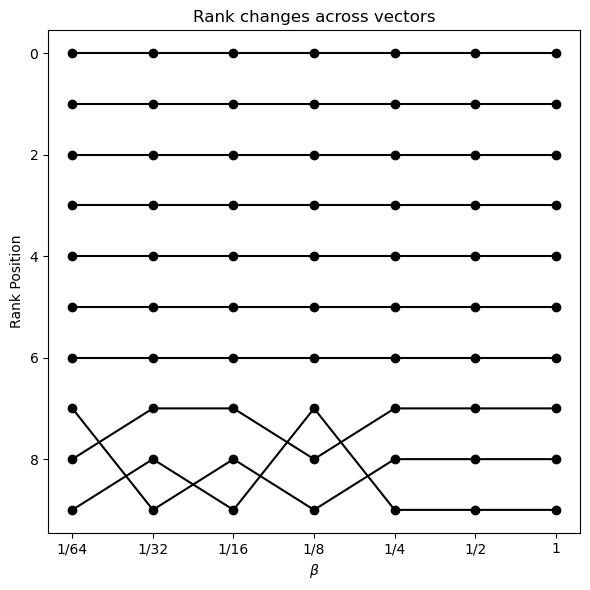

In [31]:
steps = range(ordering.shape[0])
values = range(10)

plt.figure(figsize=(6,6))

for v in values:
    positions = [np.where(ordering[i] == v)[0][0] for i in steps]
    plt.plot(steps, positions, marker='o', label=str(v), color = 'black')

plt.gca().invert_yaxis()
plt.xticks(steps, [r'1/64', r'1/32', r'1/16', r'1/8', r'1/4', r'1/2', r'1'])
plt.ylabel("Rank Position")
plt.xlabel(r"$\beta$")
plt.title("Rank changes across vectors")

#plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Best Model

In [19]:
files = [f"/home/paolo/Thesis/Na/mc_norm_rung_2/trace_model_{i}.nc" for i in range(10)]
traces_list = [az.from_netcdf(f) for f in files]
traces1 = traces_list

In [21]:
c0_post = []
a0_post = []
models_stored = 10
for m in range(models_stored):
    c0_post.append(np.mean(traces1[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces1[m].posterior['a0'].values.flatten()))
c0_post, a0_post

([np.float64(-11.39427263499985),
  np.float64(-11.26457939845749),
  np.float64(-11.124695747640995),
  np.float64(-10.903859684993973),
  np.float64(-11.034165507484314),
  np.float64(-11.530233895848491),
  np.float64(-11.199444112592174),
  np.float64(-11.085638415884917),
  np.float64(-10.361282062235878),
  np.float64(-11.117406246346407)],
 [np.float64(-0.6562558252107696),
  np.float64(-0.6706958974623014),
  np.float64(-0.6847412309619519),
  np.float64(-0.7056083465030777),
  np.float64(-0.687095678437478),
  np.float64(0.673679787369886),
  np.float64(-0.6726959347424162),
  np.float64(-0.6844517392676209),
  np.float64(-0.6939825314397958),
  np.float64(0.6820434512901513)])

In [30]:
c0_post[0], a0_post[0]

(np.float64(-11.39427263499985), np.float64(-0.6562558252107696))

In [31]:
c0_post_std[0], a0_post_std[0]

(np.float64(0.059659312740984745), np.float64(0.004356696732114809))

In [22]:
c0_post_std = []
a0_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces1[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces1[m].posterior['a0'].values.flatten()))
c0_post_std, a0_post_std

([np.float64(0.059659312740984745),
  np.float64(0.06288797996511086),
  np.float64(0.06483765763002546),
  np.float64(0.06664650530059694),
  np.float64(0.06659828939006619),
  np.float64(0.06307374705587655),
  np.float64(0.0650971679345513),
  np.float64(0.06664433197396867),
  np.float64(0.07201192463577864),
  np.float64(0.06672416095538217)],
 [np.float64(0.004356696732114809),
  np.float64(0.004636046812951821),
  np.float64(0.004809594361983336),
  np.float64(0.004977466881017108),
  np.float64(0.004886981019457733),
  np.float64(0.0048022418089809105),
  np.float64(0.004769632637731308),
  np.float64(0.004908500445088355),
  np.float64(0.004994108831161927),
  np.float64(0.004919987463841408)])

In [23]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]))

In [24]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [25]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [26]:
np.sqrt(np.mean((y_obs - y_post)**2, axis = 0))

array([0.40325076, 0.414864  , 0.42296367, 0.42678989, 0.42846641,
       0.42915005, 0.43043025, 0.43415474, 0.43437814, 0.43438805])

In [28]:
y_obs_test = np.tile(data_test['logD'], (10,1)).T

In [29]:
np.sqrt(np.mean((y_obs_test - y_post_test)**2, axis = 0))

array([0.40923548, 0.41774762, 0.42241084, 0.42274476, 0.43269083,
       0.43342657, 0.4337252 , 0.43325336, 0.43430524, 0.43303148])

## Calibration

In [39]:
traces1[0].posterior['c0'].values.flatten()

array([-11.36207552, -11.33011686, -11.46791864, ..., -11.42372363,
       -11.39450065, -11.46141777], shape=(16000,))

In [20]:
# files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm2_lnD/trace_model_{i}.nc" for i in range(10)]
# traces_list = [az.from_netcdf(f) for f in files]
# traces1 = traces_list

In [40]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
sigma_samples_list = []
models_stored = 10
for m in range(models_stored):
# Draws 50 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces1[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces1[m].posterior['a0'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces1[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

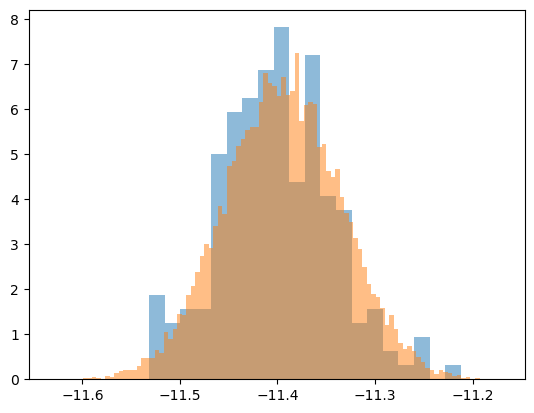

In [41]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces1[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [42]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m])
# Empirical mean over the models
y_emp

array([[-22.2441777 , -22.01024948, -21.88260871, ..., -21.86974149,
        -21.9148137 , -21.87538766],
       [-23.05608622, -22.97831466, -22.93068938, ..., -22.96123274,
        -22.94630902, -22.96385615],
       [-17.80344861, -17.80716765, -17.80392096, ..., -17.81243359,
        -17.83291936, -17.82702101],
       ...,
       [-23.35383072, -23.33226182, -23.30930311, ..., -23.29453697,
        -23.30401931, -23.29623734],
       [-20.51190845, -20.40217137, -20.32452356, ..., -20.32027081,
        -20.29692512, -20.31844526],
       [-24.20693408, -24.29442406, -24.28903788, ..., -24.33105708,
        -24.33215941, -24.32573142]], shape=(1041, 10))

In [43]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.17205847, 0.18213668, 0.19174343, ..., 0.20089669, 0.20250751,
        0.20048858],
       [0.17282642, 0.18313533, 0.19296587, ..., 0.20212637, 0.20378979,
        0.20174941],
       [0.16883229, 0.17879279, 0.18806563, ..., 0.19742009, 0.19857344,
        0.19693886],
       ...,
       [0.17312185, 0.18352181, 0.19343536, ..., 0.20252676, 0.20426161,
        0.2021603 ],
       [0.17060404, 0.18066687, 0.19013575, ..., 0.19936542, 0.20073043,
        0.19891083],
       [0.1740093 , 0.18463021, 0.19471894, ..., 0.20384625, 0.20569558,
        0.20350982]], shape=(1041, 10))

In [44]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [45]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.95510404, 0.95396773, 0.94187018, 0.94699311, 0.94558105,
       0.95503903, 0.94179997, 0.9467013 , 0.94119171, 0.94940641])

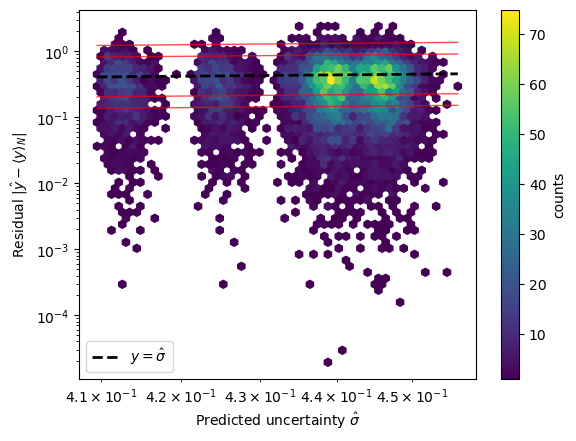

In [48]:
x = np.sqrt(var_emp)  # predicted uncertainty σ̂
y = np.abs(y_obs - y_emp)  # empirical error (not squared)

# reference line y = x  (error = σ)
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label=r'$y = \hat{\sigma}$')

# sigma lines: y = n·σ
sigma_multipliers = [1/3, 1/2, 2, 3]
for n in sigma_multipliers:
    plt.plot(xline, n * xline,
             linestyle='-',
             color='red',
             lw=1,
             alpha=0.7)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')
plt.colorbar(label='counts')
plt.xlabel(r'Predicted uncertainty $\hat{\sigma}$')
plt.ylabel(r'Residual $|\hat y - \langle y \rangle_N|$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

## Within Alpha

In [49]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

In [50]:
y_test = np.array(data_test['logD'])

In [55]:
# files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm2_lnD/pp_model_{i}.nc" for i in range(10)]
# ppcs = [az.from_netcdf(f) for f in files_ppc]

In [30]:
files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm_lnD/pp_model_{i}.nc" for i in range(10)]
ppcs = [az.from_netcdf(f) for f in files_ppc]

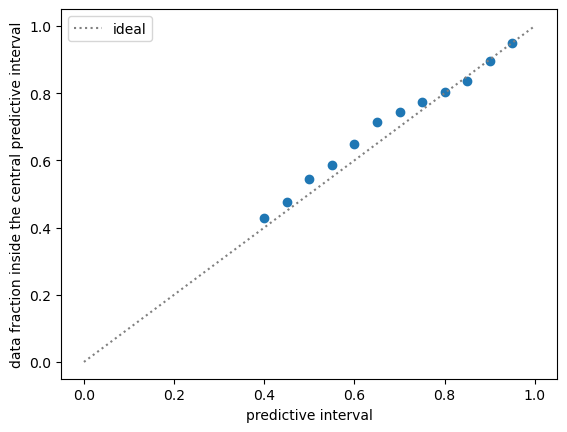

In [51]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[0].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

# E vs Rest

In [32]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
EvsRest = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "E": data['E']
})    

## SISSO Initialization

In [33]:
n_feat = 39
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/final/Na_Ea{n_feat}_temp300_unitless.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/final/Na_Ea{n_feat}_temp300_unitless.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [40]:
# Try the fit with the exact functional form
rung = 2
desc_dim = 1
Diff_json = {
    'data_file': data_file,
     'property_key': 'E',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/final/Ea{n_feat}_{rung}_{desc_dim}_unitless.json", "w"), indent=4)

## Formula Extraction

In [22]:
def extract_dd1_Ea(ms = 10, rung=2, feat = 39):
    '''Extract the Ea formulas and the values of the parameters from the SISSO output for desc_dim=1 and Rung=2'''
    dd = 1
    formulas = []
    a0_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/final/models_Ea{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            c0_i = parts[4].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, c0_list)

In [23]:
raw_formulas2, a0_list2, c0_list2 =extract_dd1_Ea()

In [24]:
raw_formulas2

['c0 + a0 * ((O - NBI) * (face-area-avg - Ge))',
 'c0 + a0 * ((O - NBI) * (face-area-avg + B))',
 'c0 + a0 * ((O - NBI) * (face-area-avg - poly_dist_avg))',
 'c0 + a0 * ((O - NBI) * (face-area-avg + face-area-max))',
 'c0 + a0 * ((O - NBI) * (face-area-avg - poly_dist_avg_fixed))',
 'c0 + a0 * ((O - NBI) * (face-area-avg * NBI))',
 'c0 + a0 * ((B + SBI) + (face-area-avg / WE))',
 'c0 + a0 * ((WE / RBI) + (face-area-avg + B))',
 'c0 + a0 * ((WE / RBI) + (B + AAV))',
 'c0 + a0 * ((S + NBI) * (poly_dist_avg + PF))']

In [25]:
def sanitize(expr):
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [26]:
formulas2 = [sanitize(f) for f in raw_formulas2]
formulas2

['c0 + a0 * ((O - NBI) * (face_area_avg - Ge))',
 'c0 + a0 * ((O - NBI) * (face_area_avg + B))',
 'c0 + a0 * ((O - NBI) * (face_area_avg - poly_dist_avg))',
 'c0 + a0 * ((O - NBI) * (face_area_avg + face_area_max))',
 'c0 + a0 * ((O - NBI) * (face_area_avg - poly_dist_avg_fixed))',
 'c0 + a0 * ((O - NBI) * (face_area_avg * NBI))',
 'c0 + a0 * ((B + SBI) + (face_area_avg / WE))',
 'c0 + a0 * ((WE / RBI) + (face_area_avg + B))',
 'c0 + a0 * ((WE / RBI) + (B + AAV))',
 'c0 + a0 * ((S + NBI) * (poly_dist_avg + PF))']

In [27]:
a0_2 = np.array(a0_list2, dtype=float)
c0_2 = np.array(c0_list2, dtype=float)

In [28]:
# Coefficients are separated from function blocks to be later added as distributions
a0_sym, c0_sym = sp.symbols('a0 c0')
symbols = sp.symbols(
    '''
    Ea B N O F Na Al Si P S Cl Ge Br I
    rho AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas2]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
    ]
    pruned.append(row)

pruned

[[(Ge - face_area_avg)*(NBI - O)],
 [-(B + face_area_avg)*(NBI - O)],
 [-(NBI - O)*(face_area_avg - poly_dist_avg)],
 [-(NBI - O)*(face_area_avg + face_area_max)],
 [-(NBI - O)*(face_area_avg - poly_dist_avg_fixed)],
 [NBI*face_area_avg*(-NBI + O)],
 [B + SBI + face_area_avg/WE],
 [B + face_area_avg + WE/RBI],
 [AAV + B + WE/RBI],
 [(NBI + S)*(PF + poly_dist_avg)]]

In [29]:
vars_ = [
    locals_dict[k] for k in [
        'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'rho', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [30]:
data = initialize_units(data_train)
X = np.array([
    phi(
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [31]:
data2 = initialize_units(data_test)
X_test = np.array([
    phi(
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [32]:
X

array([[[ 1.90178300e-02,  2.51692121e-02, -4.16441122e-01, ...,
          2.07369369e-01, -5.92848412e-04,  3.37064807e-01]],

       [[ 1.71348348e-02,  1.48931220e-02, -4.70841905e-01, ...,
          1.78111178e-01, -3.98514252e-02,  3.37064807e-01]],

       [[ 2.75947747e-02,  8.31490204e-02, -3.79199554e-01, ...,
          2.50470684e-01,  2.35239337e-02,  4.28143694e-01]],

       ...,

       [[ 7.36742973e-01,  7.33303318e-01,  1.76842442e+00, ...,
          2.40676914e-02,  1.06841097e+00, -3.38967746e-01]],

       [[ 1.83977646e-01,  3.87434381e-01,  1.67340419e+00, ...,
          1.36636795e-01,  5.86154927e-01, -1.71120047e-01]],

       [[ 4.77666074e-01,  4.83839980e-01,  3.27177764e-01, ...,
          5.98314641e-01,  4.21872469e-01,  6.97050251e-01]]],
      shape=(10, 1, 1041))

In [25]:
traces2 = []
ppcs2 = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors, Che valori di sigma potrei usare? 10 forse è un po' troppo
        c0_coeff = pm.Normal("c0", mu=c0_2[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0_2[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] 

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data['E'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        
        #trace = pm.sample()
        traces2.append(trace)
        ppcs2.append(ppc)
        
        idata = trace.posterior
        az.to_netcdf(idata, f"trace2_model_{i}.nc")
        az.to_netcdf(ppc, f"pp2_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [26]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces2[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-1123.72446441 -1123.61732502 -1123.5957653  -1123.62203078]
[-1129.06096857 -1128.88283308 -1128.94549617 -1128.96621355]
[-1129.44978562 -1129.38796228 -1129.40993457 -1129.53124209]
[-1131.61357736 -1131.65232072 -1131.65496952 -1131.5395453 ]
[-1132.62365124 -1132.6551459  -1132.62013552 -1132.55956796]
[-1132.38937993 -1132.48451716 -1132.36470576 -1132.43621339]
[-1133.22393357 -1133.18337226 -1133.20387742 -1133.22696534]
[-1135.30148418 -1135.25771584 -1135.18158089 -1135.28520303]
[-1135.95870466 -1135.90052578 -1135.84884984 -1135.84128897]
[-1134.30368114 -1134.23677524 -1134.33757987 -1134.41002402]


In [27]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml

(np.float64(-1123.6398963758822), np.int64(0))

In [28]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(0.004873312115056798),
 np.float64(0.003012952556217189),
 np.float64(0.00034388376590008274),
 np.float64(0.00012656826149289548),
 np.float64(0.00015396154660015317),
 np.float64(6.981645914655007e-05),
 np.float64(9.015190152125807e-06),
 np.float64(4.797354501747572e-06),
 np.float64(2.2951696745033472e-05)]

In [29]:
np.argsort(ml_diff)

array([8, 7, 9, 6, 4, 5, 3, 2, 1, 0])

## Best Model

In [45]:
# Monte Carlo posteriors
files = [f"/home/paolo/Thesis/Na/mc_norm_rung_2_Ea/trace2_model_{i}.nc" for i in range(10)]
traces_list2 = [az.from_netcdf(f) for f in files]
traces2 = traces_list2

In [46]:
c0_post = []
a0_post = []
models_stored = 10
for m in range(models_stored):
    c0_post.append(np.mean(traces2[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces2[m].posterior['a0'].values.flatten()))

In [61]:
c0_post[7], a0_post[7]

(np.float64(0.8496885190399321), np.float64(-0.8973304022697878))

In [47]:
c0_post_std = []
a0_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces2[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces2[m].posterior['a0'].values.flatten()))
c0_post_std, a0_post_std

([np.float64(0.022381370324351148),
  np.float64(0.023088853733473844),
  np.float64(0.022039807182811972),
  np.float64(0.022693435761730767),
  np.float64(0.02210452852063584),
  np.float64(0.022497443380958916),
  np.float64(0.028044110058434102),
  np.float64(0.03451378342535798),
  np.float64(0.035718519992924455),
  np.float64(0.08170759017662221)],
 [np.float64(0.06607519122786025),
  np.float64(0.06588721646634373),
  np.float64(0.06322176584464488),
  np.float64(0.034755025875513164),
  np.float64(0.0637064092709233),
  np.float64(0.1270141105336183),
  np.float64(0.0629932390925245),
  np.float64(0.028083034386989697),
  np.float64(0.02992380880961844),
  np.float64(0.1680519916098225)])

In [48]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) )

In [49]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [50]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [51]:
np.sqrt(np.mean((y_obs - y_post)**2, axis = 0))

array([0.70161237, 0.70524119, 0.70552194, 0.70658604, 0.70770902,
       0.70800575, 0.70808587, 0.70896523, 0.70944329, 0.70953205])

In [57]:
y_obs_test = np.tile(data2['E'], (10,1)).T
y_obs_test

array([[-0.64586049, -0.64586049, -0.64586049, ..., -0.64586049,
        -0.64586049, -0.64586049],
       [ 0.43108133,  0.43108133,  0.43108133, ...,  0.43108133,
         0.43108133,  0.43108133],
       [-1.40381703, -1.40381703, -1.40381703, ..., -1.40381703,
        -1.40381703, -1.40381703],
       ...,
       [-0.45995973, -0.45995973, -0.45995973, ..., -0.45995973,
        -0.45995973, -0.45995973],
       [ 0.42330327,  0.42330327,  0.42330327, ...,  0.42330327,
         0.42330327,  0.42330327],
       [ 0.4496343 ,  0.4496343 ,  0.4496343 , ...,  0.4496343 ,
         0.4496343 ,  0.4496343 ]], shape=(261, 10))

In [58]:
np.sqrt(np.mean((y_obs_test - y_post_test)**2, axis = 0))

array([0.71648271, 0.7187623 , 0.72075177, 0.70981881, 0.72068856,
       0.72543494, 0.70719714, 0.70142627, 0.72128549, 0.70670992])

ottavo modello, indice:7

In [60]:
# test R^2
from sklearn.metrics import r2_score
r2_score(y_obs_test.T[0], y_post_test.T[0]), r2_score(y_obs_test.T[7], y_post_test.T[7])

(0.48467811007966366, 0.5061088903397802)

## Calibration

In [39]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
sigma_samples_list = []
for m in range(models_stored):
# Draws 50 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces2[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces2[m].posterior['a0'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces2[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

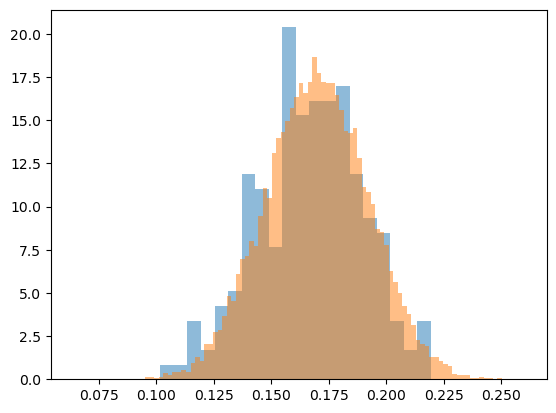

In [40]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces2[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [41]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        f = X[m, :, :]
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m])
# Empirical mean over the models
y_emp

array([[ 0.20736252,  0.25906176,  0.1444546 , ...,  0.1910833 ,
         0.73313867,  0.05333572],
       [ 0.22060447,  0.25430307,  0.25836827, ...,  0.19416571,
         0.53844262,  0.08682559],
       [-0.73004052, -0.77681057, -0.68967488, ..., -0.7334467 ,
        -0.69215435, -0.76297637],
       ...,
       [ 0.61282279,  0.60078079,  0.6014604 , ...,  0.82973944,
         0.77844106,  0.70778445],
       [ 0.16514704,  0.13809187,  0.13610736, ..., -0.10613733,
         0.34827883, -0.24931234],
       [ 0.89201535,  0.93820602,  0.9657779 , ...,  1.15506966,
         1.07294614,  1.24336806]], shape=(1041, 10))

In [42]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        f = X[m, :, :]
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.49899361, 0.50099467, 0.50416457, ..., 0.50657049, 0.51190418,
        0.52267814],
       [0.49899362, 0.50099523, 0.50418786, ..., 0.5065659 , 0.51205066,
        0.52287672],
       [0.49985717, 0.50228339, 0.50468015, ..., 0.50883518, 0.51461475,
        0.51851838],
       ...,
       [0.49914801, 0.50108426, 0.50439403, ..., 0.50603694, 0.51188025,
        0.52695766],
       [0.49899586, 0.50102416, 0.50416375, ..., 0.50710603, 0.5122621 ,
        0.52098334],
       [0.49943966, 0.50142328, 0.50483656, ..., 0.50608898, 0.51181816,
        0.53108538]], shape=(1041, 10))

In [43]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [44]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.9857783 , 0.99183119, 0.98665356, 0.99010446, 0.98600813,
       0.99396257, 0.99084799, 0.99051065, 0.98067039, 0.96253569])

## Within Alpha

In [8]:
files_ppc2 = [f"/home/paolo/Thesis/Na/pp_norm_rung_2_Ea/pp2_model_{i}.nc" for i in range(10)]
ppcs2 = [az.from_netcdf(f) for f in files_ppc2]

In [9]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

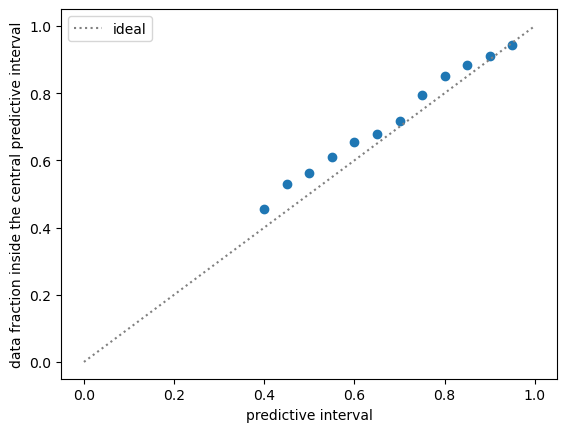

In [34]:
walphas=[]
y_test = np.array(data2['E'])
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs2[0].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
#plt.savefig('within.png')
plt.show()